In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import featuretools as ft
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFECV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
ft1 = pd.read_csv('cstlisten.csv')

In [5]:
ft1

,Week number,A(H1N1),A(H3N2),A(unknown),B,Influenza 2020-2021 (%),Influenza 2019-2020 (%),Temperature,Wind_speed,Surface_Pressure,NO,PM2.5,SO2,CO,Year,total_flu,total_A,relative_humidity,NO_SO2
0,23.0,0.0,0.0,0.0,1.0,6.260976,5.226923,11.946286,6.024857,100.493714,0.001473,9.729600,0.005577,506.718000,2015.0,1.0,0.0,76.634404,0.000008
1,40.0,0.0,3.0,5.0,6.0,6.260976,5.226923,11.740286,2.657714,102.480000,0.005648,11.686000,0.008509,427.469429,2015.0,14.0,8.0,82.017244,0.000048
2,41.0,6.0,2.0,21.0,2.0,6.260976,5.226923,12.106857,3.706857,100.503714,0.005648,11.686000,0.008509,751.117143,2015.0,31.0,29.0,90.151233,0.000048
3,42.0,7.0,0.0,6.0,5.0,6.260976,5.226923,9.672000,3.170000,101.436286,0.005648,11.686000,0.008509,462.478571,2015.0,18.0,13.0,84.163767,0.000048
4,43.0,6.0,1.0,5.0,4.0,6.260976,5.226923,10.287143,3.145143,101.372000,0.005648,11.686000,0.008509,577.775857,2015.0,16.0,12.0,89.044841,0.000048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,25.0,0.0,18.0,25.0,6.0,6.260976,5.226923,13.256786,3.978214,99.964123,0.194743,6.124571,1.996857,173.231429,2024.0,49.0,43.0,84.514239,0.388874
368,26.0,1.0,16.0,16.0,0.0,6.260976,5.226923,16.717419,3.496461,100.455179,0.233429,4.631429,1.966571,190.740000,2024.0,33.0,33.0,84.442906,0.459054
369,27.0,3.0,13.0,12.0,6.0,6.260976,5.226923,13.947321,4.243409,100.288555,0.316657,5.722286,1.929714,234.791429,2024.0,34.0,28.0,83.120743,0.611058
370,28.0,0.0,29.0,18.0,4.0,6.260976,5.226923,14.340097,4.486705,99.996721,0.202571,6.187143,2.112286,203.965714,2024.0,51.0,47.0,87.238200,0.427889


In [15]:
fg = ft1.copy()

In [16]:
# Dropping specific columns from the DataFrame ft
fg.drop(columns=['A(H1N1)', 'A(H3N2)', 'A(unknown)', 'B'], inplace=True)


In [19]:
fg.drop(columns=['total_A'], inplace=True)

In [20]:
fg.dtypes

Week number                float64
Influenza 2020-2021 (%)    float64
Influenza 2019-2020 (%)    float64
Temperature                float64
Wind_speed                 float64
Surface_Pressure           float64
NO                         float64
PM2.5                      float64
SO2                        float64
CO                         float64
Year                       float64
total_flu                  float64
relative_humidity          float64
NO_SO2                     float64
dtype: object

In [32]:
fg

,Week number,Influenza 2020-2021 (%),Influenza 2019-2020 (%),Temperature,Wind_speed,Surface_Pressure,NO,PM2.5,SO2,CO,Year,total_flu,relative_humidity,NO_SO2
0,23.0,6.260976,5.226923,11.946286,6.024857,100.493714,0.001473,9.729600,0.005577,506.718000,2015.0,1.0,76.634404,0.000008
1,40.0,6.260976,5.226923,11.740286,2.657714,102.480000,0.005648,11.686000,0.008509,427.469429,2015.0,14.0,82.017244,0.000048
2,41.0,6.260976,5.226923,12.106857,3.706857,100.503714,0.005648,11.686000,0.008509,751.117143,2015.0,31.0,90.151233,0.000048
3,42.0,6.260976,5.226923,9.672000,3.170000,101.436286,0.005648,11.686000,0.008509,462.478571,2015.0,18.0,84.163767,0.000048
4,43.0,6.260976,5.226923,10.287143,3.145143,101.372000,0.005648,11.686000,0.008509,577.775857,2015.0,16.0,89.044841,0.000048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,25.0,6.260976,5.226923,13.256786,3.978214,99.964123,0.194743,6.124571,1.996857,173.231429,2024.0,49.0,84.514239,0.388874
368,26.0,6.260976,5.226923,16.717419,3.496461,100.455179,0.233429,4.631429,1.966571,190.740000,2024.0,33.0,84.442906,0.459054
369,27.0,6.260976,5.226923,13.947321,4.243409,100.288555,0.316657,5.722286,1.929714,234.791429,2024.0,34.0,83.120743,0.611058
370,28.0,6.260976,5.226923,14.340097,4.486705,99.996721,0.202571,6.187143,2.112286,203.965714,2024.0,51.0,87.238200,0.427889


In [44]:
print(fg['total_flu'].describe())

count     372.000000
mean      246.795699
std       516.212441
min         0.000000
25%        12.000000
50%        46.000000
75%       184.000000
max      3849.000000
Name: total_flu, dtype: float64


# LSTM

#### Using mean_squared_error as the loss function

In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping
import math

# Define Y as 'total_flu' and remove it from X to avoid data leakage
Y = fg['total_flu']
X = fg.drop(columns=['total_flu'])

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Scale the features to [0, 1] range (required for LSTMs)
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_Y = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_Y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_Y.transform(y_test.values.reshape(-1, 1))

# Reshape input for LSTM (LSTM expects input as [samples, time steps, features])
X_train_scaled = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_scaled = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Build LSTM model without Dropout, but with EarlyStopping
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])))
model.add(LSTM(units=50))
model.add(Dense(1))  # Output layer for regression

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Add EarlyStopping callback (monitor validation loss, patience=5)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with early stopping
history = model.fit(X_train_scaled, y_train_scaled, 
                    epochs=100, 
                    batch_size=32, 
                    validation_split=0.2,  # Split the training data for validation
                    callbacks=[early_stopping], 
                    verbose=0)  # verbose=0 for no output

# Make predictions on the test set
y_pred_scaled = model.predict(X_test_scaled)

# Inverse transform the scaled predictions and actual values
y_pred = scaler_Y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_Y.inverse_transform(y_test_scaled)

# Calculate evaluation metrics
mse = mean_squared_error(y_test_actual, y_pred)
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = math.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred)


# Create a DataFrame for the metrics
metrics_df = pd.DataFrame({
    'Metric': ['R-squared', 'MSE', 'MAE', 'RMSE'],
    'Value': [r2, mse, mae, rmse]
})

# Display the DataFrame as a table
metrics_df.style.set_caption('LSTM Model Evaluation Metrics')


,Metric,Value
0,R-squared,0.206033
1,MSE,242647.737283
2,MAE,299.909446
3,RMSE,492.592872


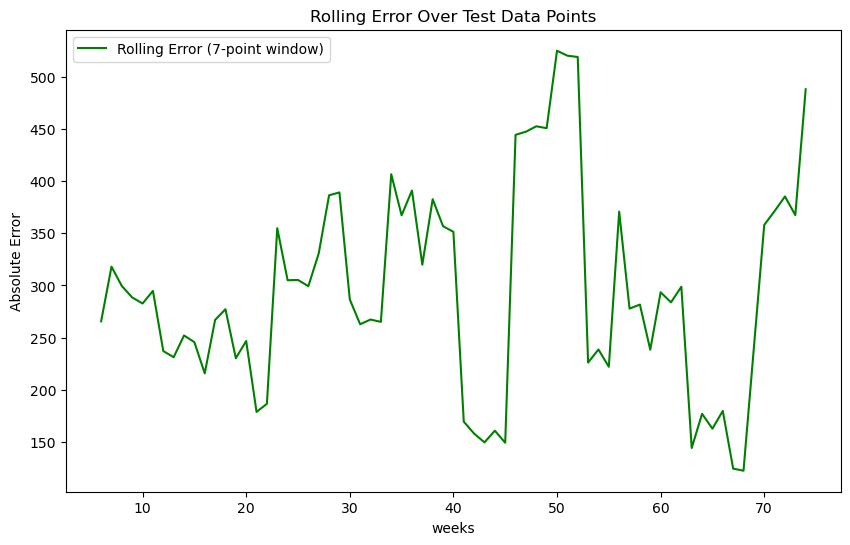

In [54]:
# Flatten arrays if needed
y_test_actual = y_test_actual.flatten()
y_pred = y_pred.flatten()

# Calculate absolute error between actual and predicted values
error = np.abs(y_test_actual - y_pred)

# Create a DataFrame to store the error values
error_df = pd.DataFrame({
    'Error': error
})

# Calculate a rolling mean of the error (e.g., over a 7-point window)
rolling_error = error_df['Error'].rolling(window=7).mean()

# Plot the rolling error
plt.figure(figsize=(10, 6))
plt.plot(rolling_error, label='Rolling Error (7-point window)', color='green')
plt.title('Rolling Error Over Test Data Points')
plt.xlabel('weeks')
plt.ylabel('Absolute Error')
plt.legend()
plt.show()


# ARIMA

In [55]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

# Define Y as 'total_flu'
Y = fg['total_flu']

# Split the data into training and testing sets (80% training, 20% testing)
train_size = int(len(Y) * 0.8)
train, test = Y[:train_size], Y[train_size:]

# Fit ARIMA model (you can adjust p, d, q based on your data)
model = ARIMA(train, order=(8, 0, 3))  # Example: ARIMA(5, 1, 0), can adjust p, d, q
arima_result = model.fit()

# Make predictions on the test set
y_pred = arima_result.forecast(steps=len(test))

# Calculate evaluation metrics
mse = mean_squared_error(test, y_pred)
mae = mean_absolute_error(test, y_pred)
rmse = math.sqrt(mse)
r2 = r2_score(test, y_pred)

# Create a DataFrame for the metrics
metrics_df = pd.DataFrame({
    'Metric': ['R-squared', 'MSE', 'MAE', 'RMSE'],
    'Value': [r2, mse, mae, rmse]
})

# Display the evaluation metrics
print(metrics_df)




C:\Users\User\anaconda3\envs\tensor_flow\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\User\anaconda3\envs\tensor_flow\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


      Metric          Value
0  R-squared      -0.157874
1        MSE  156002.490593
2        MAE     298.194486
3       RMSE     394.971506


C:\Users\User\anaconda3\envs\tensor_flow\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SArima

# Multiple Linear Regression 

In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

# Define X (independent variables) and Y (dependent/target variable)
Y = fg['total_flu']  # Replace 'total_flu' with your target variable column name
X = fg.drop(columns=['total_flu'])  # Exclude the target variable from X

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Create a Multiple Linear Regression model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = math.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print(f"R-squared: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")



R-squared: 0.2685
MSE: 223563.2258
MAE: 299.0081
RMSE: 472.8247


# Random Forest

In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Assuming X and Y are your features and target respectively
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Fit the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Print the results
print(f"R-squared: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


R-squared: 0.4226
MSE: 176456.8491
MAE: 209.7225
RMSE: 420.0677


# Ridge regression

In [56]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Assuming X and Y are your features and target respectively
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Initialize RidgeCV to automatically tune alpha using cross-validation
ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5)  # Adjust alpha values as needed
ridge_cv.fit(X_train, y_train)

# Get the best alpha value
best_alpha = ridge_cv.alpha_
print(f"Best alpha from cross-validation: {best_alpha}")

# Make predictions using the model with the best alpha
y_pred_cv = ridge_cv.predict(X_test)

# Calculate evaluation metrics for the model with the best alpha
r2 = r2_score(y_test, y_pred_cv)
mse = mean_squared_error(y_test, y_pred_cv)
mae = mean_absolute_error(y_test, y_pred_cv)
rmse = np.sqrt(mse)

# Print the results
print(f"Ridge Regression with Cross-Validation - R-squared: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")



Best alpha from cross-validation: 100.0
Ridge Regression with Cross-Validation - R-squared: 0.2477
MSE: 229907.8076
MAE: 302.4941
RMSE: 479.4870


# Gradient boosting 

In [64]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Initialize and fit Gradient Boosting Regressor
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr.fit(X_train, y_train)

# Make predictions on the test set
y_pred = gbr.predict(X_test)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Print the results
print(f"Gradient Boosting Regressor - R-squared: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


Gradient Boosting Regressor - R-squared: 0.5375
MSE: 141358.0457
MAE: 206.1640
RMSE: 375.9761


In [59]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Gradient Boosting
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Initialize Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=gbr, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the model
grid_search.fit(X_train, y_train)

# Best hyperparameters
print("Best parameters:", grid_search.best_params_)

# Best estimator
best_gbr = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred = best_gbr.predict(X_test)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Calculate MSE, MAE, and RMSE
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print the results
print(f"Best Gradient Boosting Regressor - R-squared: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


Best parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300}
Best Gradient Boosting Regressor - R-squared: 0.5969
MSE: 123191.5930
MAE: 196.9630
RMSE: 350.9866


In [58]:
from sklearn.ensemble import GradientBoostingRegressor


# XGboost

In [62]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Initialize and fit XGBoost Regressor
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

# Make predictions on the test set
y_pred = xgb.predict(X_test)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Print the results
print(f"XGBoost Regressor - R-squared: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


XGBoost Regressor - R-squared: 0.0834
MSE: 280115.1983
MAE: 199.0423
RMSE: 529.2591


In [63]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for XGBoost
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Initialize XGBoost Regressor
xgb = XGBRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the model
grid_search.fit(X_train, y_train)

# Best hyperparameters
print("Best parameters:", grid_search.best_params_)

# Best estimator
best_xgb = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred = best_xgb.predict(X_test)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Calculate MSE, MAE, and RMSE
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print the results
print(f"Best XGBoost Regressor - R-squared: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}
Best XGBoost Regressor - R-squared: 0.4459
MSE: 169348.3395
MAE: 209.7506
RMSE: 411.5195


# Gaussian process regressor 

In [65]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Define a kernel for the Gaussian Process
# RBF kernel with a constant multiplier
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))

# Initialize the Gaussian Process Regressor
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)

# Fit the model on the training data
gpr.fit(X_train, y_train)

# Make predictions on the test set
y_pred = gpr.predict(X_test)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Print the results
print(f"Gaussian Process Regression - R-squared: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


Gaussian Process Regression - R-squared: -0.2244
MSE: 374193.5313
MAE: 272.0237
RMSE: 611.7136


C:\Users\User\anaconda3\envs\tensor_flow\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [66]:
fg

,Week number,Influenza 2020-2021 (%),Influenza 2019-2020 (%),Temperature,Wind_speed,Surface_Pressure,NO,PM2.5,SO2,CO,Year,total_flu,relative_humidity,NO_SO2
0,23.0,6.260976,5.226923,11.946286,6.024857,100.493714,0.001473,9.729600,0.005577,506.718000,2015.0,1.0,76.634404,0.000008
1,40.0,6.260976,5.226923,11.740286,2.657714,102.480000,0.005648,11.686000,0.008509,427.469429,2015.0,14.0,82.017244,0.000048
2,41.0,6.260976,5.226923,12.106857,3.706857,100.503714,0.005648,11.686000,0.008509,751.117143,2015.0,31.0,90.151233,0.000048
3,42.0,6.260976,5.226923,9.672000,3.170000,101.436286,0.005648,11.686000,0.008509,462.478571,2015.0,18.0,84.163767,0.000048
4,43.0,6.260976,5.226923,10.287143,3.145143,101.372000,0.005648,11.686000,0.008509,577.775857,2015.0,16.0,89.044841,0.000048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,25.0,6.260976,5.226923,13.256786,3.978214,99.964123,0.194743,6.124571,1.996857,173.231429,2024.0,49.0,84.514239,0.388874
368,26.0,6.260976,5.226923,16.717419,3.496461,100.455179,0.233429,4.631429,1.966571,190.740000,2024.0,33.0,84.442906,0.459054
369,27.0,6.260976,5.226923,13.947321,4.243409,100.288555,0.316657,5.722286,1.929714,234.791429,2024.0,34.0,83.120743,0.611058
370,28.0,6.260976,5.226923,14.340097,4.486705,99.996721,0.202571,6.187143,2.112286,203.965714,2024.0,51.0,87.238200,0.427889


In [67]:
# Save the feature_matrix to a CSV file
fg.to_csv('cstJapa.csv', index=False)